In [2]:
# pip install nilearn

# 1. Load Atlas

In [2]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Since our objective is:

- Hippocampus
- Amygdala
- Entorhinal Cortex

the best choice is actually Juelich probabilistic atlas.

In [3]:
atlas_path = (
    "/home/enooo/fsl/data/atlases/Juelich/"
    "Juelich-maxprob-thr50-1mm.nii.gz"
)

atlas = nib.load(atlas_path)
atlas_data = atlas.get_fdata()

print(np.unique(atlas_data))
print(atlas_data.shape)

[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  25.  26.  27.  28.  29.
  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.  43.
  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.  57.
  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.  71.
  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.  85.
  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.  99.
 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112. 113.
 114. 115. 116. 118. 120. 121.]
(182, 218, 182)


# 2. Define ROI labels

- For ROI extent analysis, we combine all of the target ROI labels into one binary mask.

In [4]:
roi_labels = [
    # Amygdala
    6, 7, 8, 9, 10, 11,

    # Hippocampus
    16, 17, 20, 21, 25,

    # Entorhinal cortex
    18, 19
]

**Note for users:** verify these label-name mappings against `Juelich.xml` for your installed FSL version before finalizing — atlas label numbering can change between FSL releases. Run:
```bash
grep -i "hippocamp\|amygdala\|entorhinal" /home/enooo/fsl/data/atlases/Juelich.xml
```
and cross-check the printed index attributes against the list above.

# Build combined ROI mask

For every voxel:

ROI(x,y,z) = 1 if the voxel belongs to one of the target structures, else 0.

Result: `roi_mask.shape = (182,218,182)` — a 3D binary mask of AD-relevant anatomy.

In [11]:
roi_mask = np.isin(atlas_data, roi_labels)

print("ROI voxels:", roi_mask.sum())
print("White voxels (True):", np.count_nonzero(roi_mask))
print("Black voxels (False):", roi_mask.size - np.count_nonzero(roi_mask))
print(f"Total voxels: {roi_mask.size}")  

ROI voxels: 31539
White voxels (True): 31539
Black voxels (False): 7189493
Total voxels: 7221032


In [12]:
import xml.etree.ElementTree as ET

tree = ET.parse('/home/enooo/fsl/data/atlases/Juelich.xml')
root = tree.getroot()

for label in root.iter('label'):
    idx = label.get('index')
    name = label.text
    if idx in ['16', '17', '20', '21', '25', '6','7','8','9','10','11','18','19']:
        print(f"Label {idx}: {name}")

Label 6: GM Amygdala_centromedial group L
Label 7: GM Amygdala_centromedial group R
Label 8: GM Amygdala_laterobasal group L
Label 9: GM Amygdala_laterobasal group R
Label 10: GM Amygdala_superficial group L
Label 11: GM Amygdala_superficial group R
Label 16: GM Hippocampus cornu ammonis L
Label 17: GM Hippocampus cornu ammonis R
Label 18: GM Hippocampus entorhinal cortex L
Label 19: GM Hippocampus entorhinal cortex R
Label 20: GM Hippocampus dentate gyrus L
Label 21: GM Hippocampus dentate gyrus R
Label 25: GM Hippocampus subiculum R


/tmp/ipykernel_9491/4030286898.py:43: UserWarning: kwargs['alpha']=0.8 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  display.add_overlay(hip_img, cmap=blue_cmap, alpha=0.8)
/tmp/ipykernel_9491/4030286898.py:44: UserWarning: kwargs['alpha']=0.8 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  display.add_overlay(amy_img, cmap=red_cmap, alpha=0.8)
/tmp/ipykernel_9491/4030286898.py:45: UserWarning: kwargs['alpha']=0.8 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  display.add_overlay(ent_img, cmap=green_cmap, alpha=0.8)


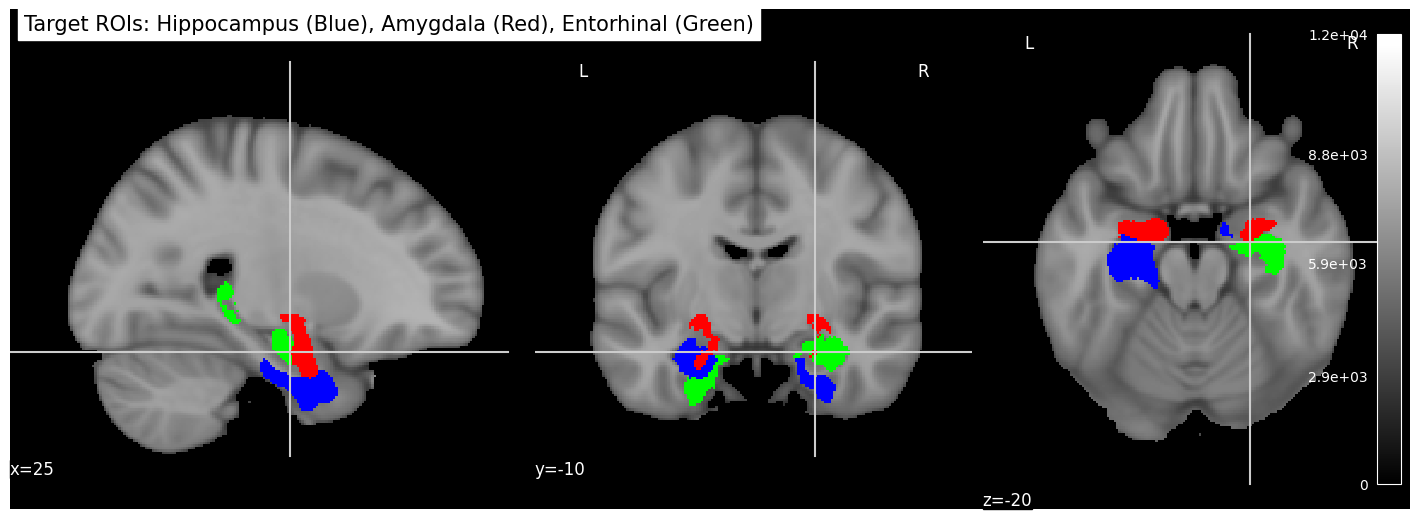

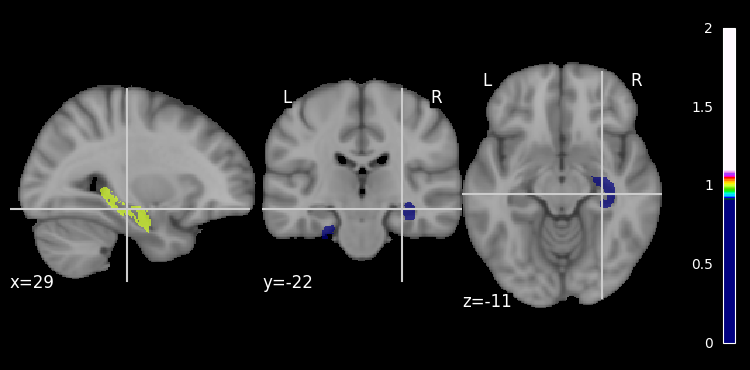

In [2]:
import nibabel as nib
import numpy as np
from nilearn import plotting
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ---------- 1. Load data ----------
mni_t1_path = "/home/enooo/fsl/data/standard/MNI152_T1_1mm_brain.nii.gz"
label_atlas_path = "/home/enooo/fsl/data/atlases/Juelich/Juelich-maxprob-thr50-1mm.nii.gz"

t1_img = nib.load(mni_t1_path)
label_img = nib.load(label_atlas_path)
label_data = label_img.get_fdata()

# ---------- 2. Build ROI masks ----------
amygdala_labels    = [6, 7, 8, 9, 10, 11]
hippocampus_labels = [16, 17, 20, 21, 25]
entorhinal_labels  = [18, 19]

def make_roi_img(label_data, labels, affine):
    mask = np.isin(label_data, labels).astype(np.int16)
    return nib.Nifti1Image(mask, affine)

amy_img = make_roi_img(label_data, amygdala_labels, label_img.affine)
hip_img = make_roi_img(label_data, hippocampus_labels, label_img.affine)
ent_img = make_roi_img(label_data, entorhinal_labels, label_img.affine)

# ---------- 3. Define SOLID single-color colormaps ----------
red_cmap   = ListedColormap(['red'])
blue_cmap  = ListedColormap(['blue'])
green_cmap = ListedColormap(['lime'])

# ---------- 4. Plot ----------
display = plotting.plot_anat(
    t1_img,
    display_mode='ortho',
    cut_coords=(25, -10, -20),
    title='Target ROIs: Hippocampus (Blue), Amygdala (Red), Entorhinal (Green)',
    figure=plt.figure(figsize=(14, 5)),
    black_bg=True
)

display.add_overlay(hip_img, cmap=blue_cmap, alpha=0.8)
display.add_overlay(amy_img, cmap=red_cmap, alpha=0.8)
display.add_overlay(ent_img, cmap=green_cmap, alpha=0.8)

plt.savefig(
    '/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv/roi_overlay_ortho_colored.png',
    dpi=200, bbox_inches='tight', facecolor='black'
)
display = plotting.plot_roi(
    ent_img,
    bg_img=t1_img,
    display_mode="ortho",
    cut_coords=None
)
plt.show()

In [3]:
hippocampus_labels = [16, 17, 20, 21, 25]
mask_hip_full = np.isin(label_data, hippocampus_labels)

coords_full = np.array(np.where(mask_hip_full)).T
print("Z range (axial) of true hippocampus voxels:", coords_full[:,2].min(), "-", coords_full[:,2].max())
print("Y range (coronal):", coords_full[:,1].min(), "-", coords_full[:,1].max())
print("X range (sagittal):", coords_full[:,0].min(), "-", coords_full[:,0].max())

Z range (axial) of true hippocampus voxels: 27 - 109
Y range (coronal): 83 - 165
X range (sagittal): 27 - 128


# Define the bounding box

In [4]:
import nibabel as nib
import numpy as np

ROI_LABELS = [6,7,8,9,10,11, 16,17,20,21,25, 18,19]

atlas = nib.load("/home/enooo/fsl/data/atlases/Juelich/Juelich-maxprob-thr50-1mm.nii.gz").get_fdata()
roi_mask = np.isin(atlas, ROI_LABELS)

# Find bounding box of the combined ROI in 3D
x_idx, y_idx, z_idx = np.where(roi_mask)

bbox = {
    'x_min': x_idx.min(), 'x_max': x_idx.max(),
    'y_min': y_idx.min(), 'y_max': y_idx.max(),
    'z_min': z_idx.min(), 'z_max': z_idx.max(),
}

# Bbox dimensions
W = bbox['x_max'] - bbox['x_min']  # width
H = bbox['y_max'] - bbox['y_min']  # height
D = bbox['z_max'] - bbox['z_min']  # depth (axial)

print(f"ROI bbox: W={W}, H={H}, D={D}")
print(bbox)

ROI bbox: W=101, H=99, D=103
{'x_min': np.int64(27), 'x_max': np.int64(128), 'y_min': np.int64(66), 'y_max': np.int64(165), 'z_min': np.int64(26), 'z_max': np.int64(129)}


In [5]:
# ---------- Create bounding box image ----------
bbox_img_data = np.zeros(label_data.shape, dtype=np.uint8)

x0, x1 = bbox['x_min'], bbox['x_max']
y0, y1 = bbox['y_min'], bbox['y_max']
z0, z1 = bbox['z_min'], bbox['z_max']

# Draw the 12 box edges (1 voxel thick)

# Along X
bbox_img_data[x0:x1+1, y0, z0] = 1
bbox_img_data[x0:x1+1, y1, z0] = 1
bbox_img_data[x0:x1+1, y0, z1] = 1
bbox_img_data[x0:x1+1, y1, z1] = 1

# Along Y
bbox_img_data[x0, y0:y1+1, z0] = 1
bbox_img_data[x1, y0:y1+1, z0] = 1
bbox_img_data[x0, y0:y1+1, z1] = 1
bbox_img_data[x1, y0:y1+1, z1] = 1

# Along Z
bbox_img_data[x0, y0, z0:z1+1] = 1
bbox_img_data[x1, y0, z0:z1+1] = 1
bbox_img_data[x0, y1, z0:z1+1] = 1
bbox_img_data[x1, y1, z0:z1+1] = 1

bbox_img = nib.Nifti1Image(bbox_img_data, label_img.affine)

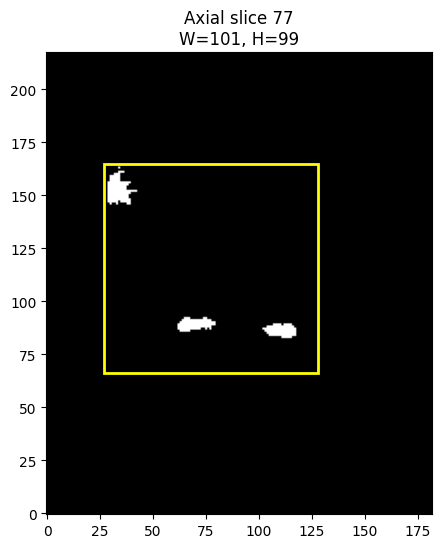

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

z = (bbox['z_min'] + bbox['z_max']) // 2

fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(roi_mask[:, :, z].T, origin='lower', cmap='gray')

rect = patches.Rectangle(
    (bbox['x_min'], bbox['y_min']),
    W,
    H,
    linewidth=2,
    edgecolor='yellow',
    facecolor='none'
)

ax.add_patch(rect)

ax.set_title(f'Axial slice {z}\nW={W}, H={H}')
plt.show()

In [7]:
def get_scaled_bbox(bbox, scale, vol_shape):
    """
    Expand bbox by (scale-1)/2 on each side.
    scale=1.0 → original ROI bbox
    scale=1.4 → 40% larger on each side
    scale=1.8 → 80% larger (context)
    Clips to volume boundary.
    """
    W = bbox['x_max'] - bbox['x_min']
    H = bbox['y_max'] - bbox['y_min']
    D = bbox['z_max'] - bbox['z_min']

    pad_x = int(W * (scale - 1) / 2)
    pad_y = int(H * (scale - 1) / 2)
    pad_z = int(D * (scale - 1) / 2)

    return {
        'x_min': max(0, bbox['x_min'] - pad_x),
        'x_max': min(vol_shape[0], bbox['x_max'] + pad_x),
        'y_min': max(0, bbox['y_min'] - pad_y),
        'y_max': min(vol_shape[1], bbox['y_max'] + pad_y),
        'z_min': max(0, bbox['z_min'] - pad_z),
        'z_max': min(vol_shape[2], bbox['z_max'] + pad_z),
    }

VOL_SHAPE = (182, 218, 182)

# Three pyramid scales
SCALES = {
    'tight'  : 1.0,   # exact ROI bbox
    'medium' : 1.4,   # 40% expansion — adds perirhinal/parahippocampal context
    'wide'   : 1.8,   # 80% expansion — adds temporal lobe context
}

bboxes = {
    name: get_scaled_bbox(bbox, scale, VOL_SHAPE)
    for name, scale in SCALES.items()
}

In [8]:
mid = label_data.shape[0] // 2

left = roi_mask[:mid]
right = roi_mask[mid:]

print("Left voxels :", left.sum())
print("Right voxels:", right.sum())

Left voxels : 16500
Right voxels: 15039


In [32]:
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

CSV_DIR     = Path("/home/enooo/Documents/Master/Early_Detection_AD/01_data/csv")
ATLAS_PATH  = Path("/home/enooo/fsl/data/atlases/Juelich/Juelich-maxprob-thr50-1mm.nii.gz")

meta = pd.read_csv(CSV_DIR / "master_metadata_affine_3t.csv")

# ── Build atlas ROI mask once ─────────────────────────────────────────────────
ROI_LABELS  = [6,7,8,9,10,11, 16,17,20,21,25, 18,19]
atlas_data  = nib.load(str(ATLAS_PATH)).get_fdata()
roi_mask    = np.isin(atlas_data, ROI_LABELS)

# Atlas bbox (fixed, MNI space — same for all subjects)
x_idx, y_idx, z_idx = np.where(roi_mask)
atlas_bbox = {
    'x_min': int(x_idx.min()), 'x_max': int(x_idx.max()),
    'y_min': int(y_idx.min()), 'y_max': int(y_idx.max()),
    'z_min': int(z_idx.min()), 'z_max': int(z_idx.max()),
}
atlas_W = atlas_bbox['x_max'] - atlas_bbox['x_min']
atlas_H = atlas_bbox['y_max'] - atlas_bbox['y_min']
atlas_D = atlas_bbox['z_max'] - atlas_bbox['z_min']

print("=== Atlas ROI bounding box (MNI space) ===")
print(f"  X: {atlas_bbox['x_min']} → {atlas_bbox['x_max']}  (W={atlas_W})")
print(f"  Y: {atlas_bbox['y_min']} → {atlas_bbox['y_max']}  (H={atlas_H})")
print(f"  Z: {atlas_bbox['z_min']} → {atlas_bbox['z_max']}  (D={atlas_D})")
print()

# ── Per-subject: find actual ROI tissue bbox ──────────────────────────────────
# For each subject, find where brain tissue exists WITHIN the atlas ROI mask.
# This tells us how large the subject's actual ROI is, which may differ
# from the atlas bbox due to atrophy, registration error, or anatomy.
rows = []

for _, row in tqdm(meta.iterrows(), total=len(meta), desc="Subjects"):
    try:
        vol = nib.load(row['file_path']).get_fdata()
    except Exception as e:
        print(f"Failed: {row['file_path']} — {e}")
        continue

    # Non-zero voxels within the atlas ROI mask
    tissue_in_roi = (vol > 0) & roi_mask

    if tissue_in_roi.sum() == 0:
        print(f"No ROI tissue found: {row['subject_id']}")
        continue

    # Find bounding box of actual tissue within the ROI mask
    tx, ty, tz = np.where(tissue_in_roi)

    rows.append({
        'subject_id' : row['subject_id'],
        'image_id'   : row['image_id'],
        'class'      : row['class'],

        # Subject's actual ROI tissue extent
        'x_min': int(tx.min()), 'x_max': int(tx.max()),
        'y_min': int(ty.min()), 'y_max': int(ty.max()),
        'z_min': int(tz.min()), 'z_max': int(tz.max()),

        # Dimensions of the subject's ROI tissue bbox
        'W': int(tx.max() - tx.min()),
        'H': int(ty.max() - ty.min()),
        'D': int(tz.max() - tz.min()),

        # Total ROI tissue voxels
        'n_roi_voxels': int(tissue_in_roi.sum()),

        # How far the subject's bbox deviates from atlas bbox center
        'x_center_offset': int(tx.mean()) - int((atlas_bbox['x_min'] + atlas_bbox['x_max']) / 2),
        'y_center_offset': int(ty.mean()) - int((atlas_bbox['y_min'] + atlas_bbox['y_max']) / 2),
        'z_center_offset': int(tz.mean()) - int((atlas_bbox['z_min'] + atlas_bbox['z_max']) / 2),
    })

voi_df = pd.DataFrame(rows)
voi_df.to_csv(CSV_DIR / "per_subject_voi_stats.csv", index=False)
print(f"\nSaved: per_subject_voi_affine_stats.csv  ({len(voi_df)} rows)")

=== Atlas ROI bounding box (MNI space) ===
  X: 27 → 128  (W=101)
  Y: 66 → 165  (H=99)
  Z: 26 → 129  (D=103)



Subjects:  66%|██████▌   | 1077/1626 [06:06<02:57,  3.10it/s]

No ROI tissue found: 022_S_2379


Subjects: 100%|██████████| 1626/1626 [09:09<00:00,  2.96it/s]


Saved: per_subject_voi_affine_stats.csv  (1625 rows)


In [33]:
# ── Statistics summary ────────────────────────────────────────────────────────
print("=== VOI size distribution across all subjects ===\n")
print(voi_df[['W','H','D','n_roi_voxels']].describe().round(2))

print("\n=== Per class breakdown ===")
print(voi_df.groupby('class')[['W','H','D','n_roi_voxels']].mean().round(2))

print("\n=== Center offset from atlas (mean ± std) ===")
for ax in ['x_center_offset','y_center_offset','z_center_offset']:
    m = voi_df[ax].mean()
    s = voi_df[ax].std()
    print(f"  {ax}: {m:.2f} ± {s:.2f} voxels")

print(f"\n=== Atlas bbox dimensions for reference ===")
print(f"  W={atlas_W}, H={atlas_H}, D={atlas_D}")

print(f"\n=== Recommended scale factors based on data ===")
for dim, atlas_dim, col in [('W', atlas_W, 'W'), ('H', atlas_H, 'H'), ('D', atlas_D, 'D')]:
    max_subj = voi_df[col].max()
    p95_subj = voi_df[col].quantile(0.95)
    scale_max = max_subj / atlas_dim
    scale_p95 = p95_subj / atlas_dim
    print(f"  {dim}: atlas={atlas_dim}, subject max={max_subj}, P95={p95_subj:.1f}")
    print(f"       scale to cover max: ×{scale_max:.2f},  scale to cover P95: ×{scale_p95:.2f}")

=== VOI size distribution across all subjects ===

             W        H        D  n_roi_voxels
count  1625.00  1625.00  1625.00       1625.00
mean     98.26    97.80   102.02      28993.97
std       2.08     2.34     1.52       1327.15
min      89.00    85.00    88.00      20715.00
25%      97.00    98.00   102.00      28228.00
50%      98.00    99.00   102.00      29148.00
75%     100.00    99.00   103.00      29853.00
max     101.00    99.00   103.00      31475.00

=== Per class breakdown ===
           W      H       D  n_roi_voxels
class                                    
AD     98.13  97.43  100.91      28117.50
CN     98.22  97.50  101.80      29079.10
EMCI   98.33  98.18  102.47      29246.36
LMCI   98.25  97.70  102.22      29013.24

=== Center offset from atlas (mean ± std) ===
  x_center_offset: 8.48 ± 1.83 voxels
  y_center_offset: -0.95 ± 1.42 voxels
  z_center_offset: -21.38 ± 1.16 voxels

=== Atlas bbox dimensions for reference ===
  W=101, H=99, D=103

=== Recommende

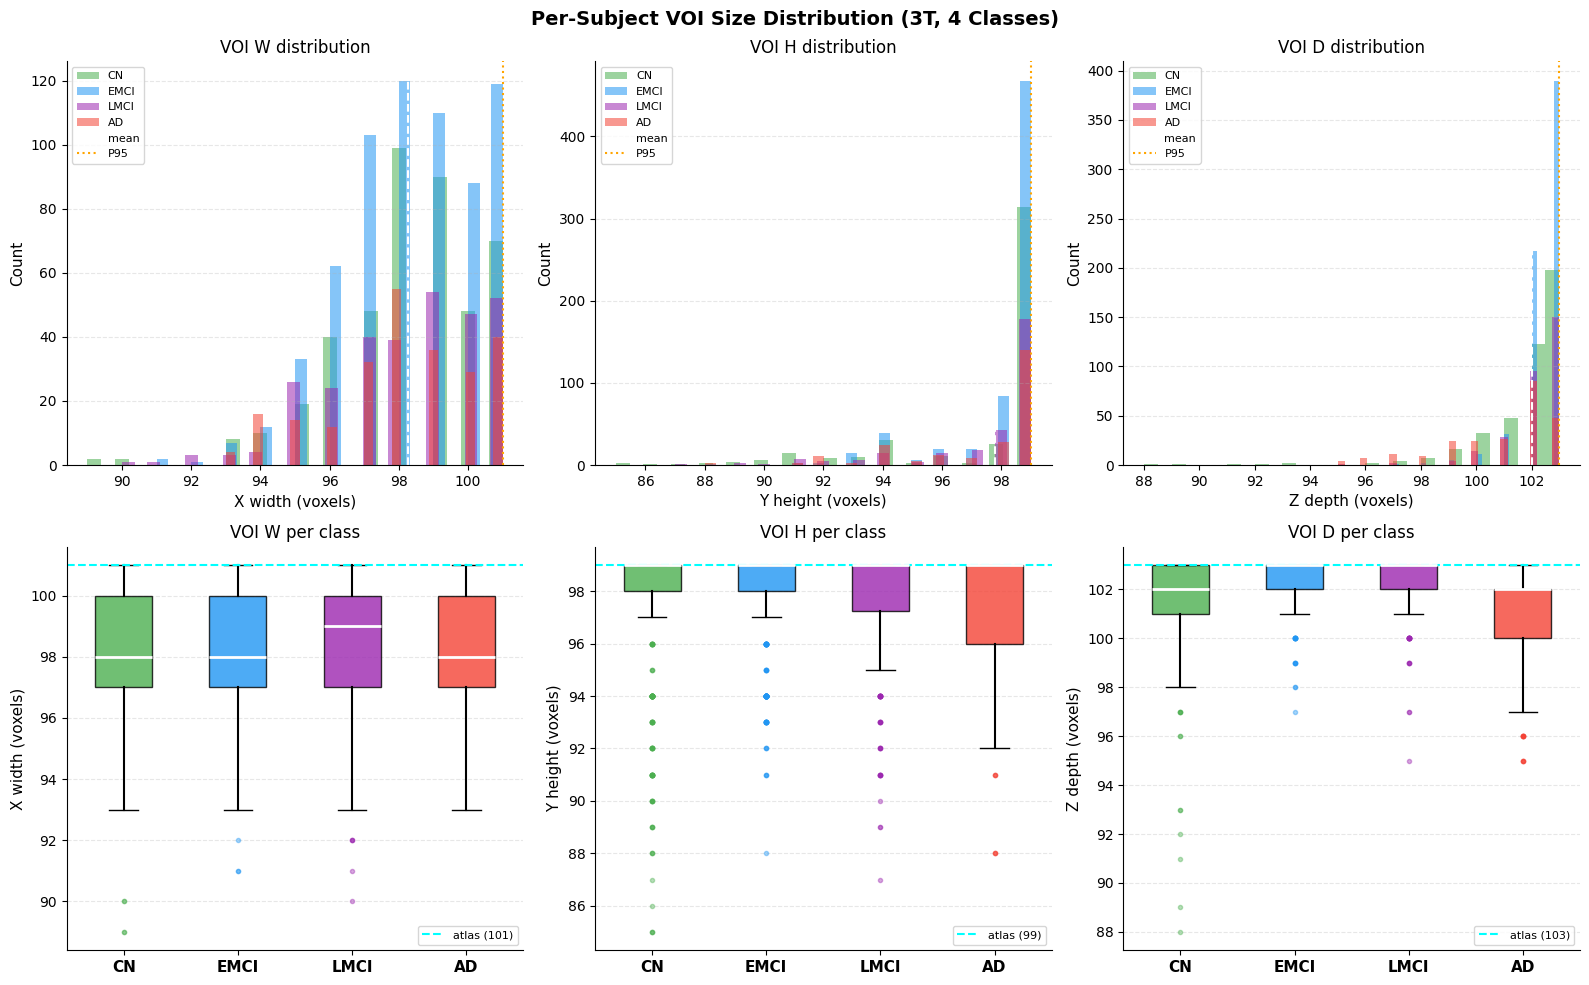

Saved -> voi_size__affine_distribution.png


In [34]:
# ── Visualization ─────────────────────────────────────────────────────────────
CLASS_COLORS = {'CN':'#4CAF50','EMCI':'#2196F3','LMCI':'#9C27B0','AD':'#F44336'}
CLASS_ORDER  = ['CN','EMCI','LMCI','AD']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Per-Subject VOI Size Distribution (3T, 4 Classes)',
             fontsize=14, fontweight='bold')

dims = [('W', 'X width (voxels)'), ('H', 'Y height (voxels)'), ('D', 'Z depth (voxels)')]

# Row 1: histograms per dimension
for j, (col, xlabel) in enumerate(dims):
    ax = axes[0, j]
    for cls in CLASS_ORDER:
        data = voi_df[voi_df['class'] == cls][col]
        ax.hist(data, bins=30, alpha=0.55, label=cls,
                color=CLASS_COLORS[cls], edgecolor='none')
    ax.axvline(voi_df[col].mean(),  color='white', linestyle='--', linewidth=1.5, label='mean')
    ax.axvline(voi_df[col].quantile(0.95), color='orange', linestyle=':', linewidth=1.5, label='P95')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'VOI {col} distribution', fontsize=12)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Row 2: boxplots per class per dimension
for j, (col, xlabel) in enumerate(dims):
    ax = axes[1, j]
    data_by_class = [voi_df[voi_df['class']==cls][col].values for cls in CLASS_ORDER]
    colors = [CLASS_COLORS[cls] for cls in CLASS_ORDER]
    bp = ax.boxplot(data_by_class, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    for flier, color in zip(bp['fliers'], colors):
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor(color)

    # Add atlas reference line
    atlas_ref = [atlas_W, atlas_H, atlas_D][j]
    ax.axhline(atlas_ref, color='cyan', linestyle='--', linewidth=1.5, label=f'atlas ({atlas_ref})')
    ax.set_xticks([1,2,3,4])
    ax.set_xticklabels(CLASS_ORDER, fontsize=11, fontweight='bold')
    ax.set_ylabel(xlabel, fontsize=11)
    ax.set_title(f'VOI {col} per class', fontsize=12)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(CSV_DIR / 'voi_size__affine_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> voi_size__affine_distribution.png")